![MLU Logo](https://drive.corp.amazon.com/view/bwernes@/MLU_Logo.png?download=true)

# <a name="0">MATH - Lecture 3 - 01 - Probabilities</a>
 

* <a href="#99">ML Business Problem: Hypothesis Testing</a> (A/B Testing)


* <a href="#1">Probability </a> 
* <a href="#2">Random Variables</a> 
* <a href="#3">Discrete Distributions</a>
* <a href="#4">Continuous Distributions</a>
    
* <a href="#100">Summary</a> 


In [1]:
# Upgrade dependencies
#!pip install --upgrade pip
#!pip install --upgrade scikit-learn

# Import our standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math as math
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")


## <a name="99">Business Problem: Hypothesis Testing (AB Testing)</a> 
(<a href="#0">Go to top</a>)

Maybe it’d be better to have a row of other recommendations instead of “Amazon’s Choice” on the website. But how do we know? We can put another version of the site in production and see which version has a higher rate of visitors purchasing. So, how do we do this mathematically? 

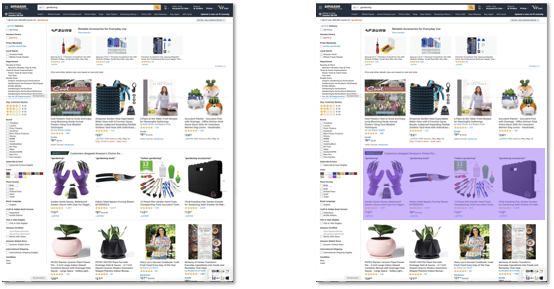

A __hypothesis test__ is a way of evaluating some evidence against the default statement about a population. We refer the default statement as the *null hypothesis*, which we try to reject using the observed data. The *alternative hypothesis* is a statement that is contrary to the null hypothesis. In our case, the null hypothesis will be that there is no difference between the two websites, and the alternate will be that there is.

The data is collected from visitors to each website, the control group (visitors who see the current website recommendations) and the test group (visitors who will experience the new website), both in identical environment setups except clicking on the recommendations. In this way, the influence of all other variables are minimized, except the impact of the independent variable in the treatment. The data from both goups is measured by the same metrics, and the metrics are compared.

There are still a few details to think about carefully. For example, what is a suitable metric to use to model the success of a new design? How many visitors to the websites so we can be confident to claim the effectiveness of the new website? How do we decide if there is a difference between the two groups? And so on. To complete the story of how to work with hypothesis testing, we need to introduce some additional concepts and terminology, especially mathematical concepts related to randomness and uncertainty in the data collection or in the visitors behavior.


## <a name="2">Probability</a> 
(<a href="#0">Go to top</a>)

When rolling a die or flipping a coin, we could in theory know enough about it to perfectly predict what the outcome will be (know the exact speed, position, shape of the object, angular velocity, the laws of physics should take over), however this can never be done in practice, the process is too complex to model. To us, a die or a coin is essentially unpredictable.

Similarly, a person's behavior, or the behavior of a computational system (like say a CPU usage in a server farm) is similarly unpredictable to us. Thus, when we try to model any such system, we need to incorporate the concept of randomness into it. 

One way to quantify the uncertainty associated with events chosen from an universe of all possible events, is through *probability*. For instance, when flipping a coin we want to know what is chance of seeing a $\{head\}$ rather than a $\{tail\}$. If the die is fair, both outcomes $\{head, tail\}$ are equally likely to occur, and thus we would expect to get a $\{head\}$ half of the times. Formally we state that $\{head\}$  occurs with probability $P(head) = \frac{1}{2}$.

But in reality, we can flip the coin say 10 times and rarely or never get a $\{head\}$. What is at play here, is that when looking at some possible event, the *probability* of the event encodes the fraction of the time that outcome would occur with *(a larger number of) repeated experiments*. 

Let's see what happens when we flip the coin 1000 times. After each flip, we record the total frequency of heads observed in the sequence, and plot the frequency counts as a function of the number of coin flips. The plot also includes a horizontal line along the actual probability of 0.5. It is worth pointing out that ```np.random.randint(0, 2)``` generates random values of $0$ and $1$, which will stay for $\{tail\}$ and $\{head\}$,

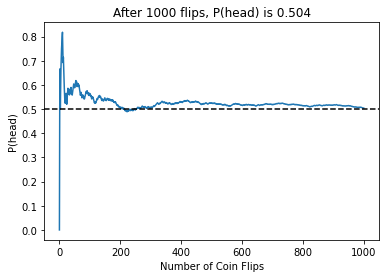

In [2]:
np.random.seed(0)

n = 1000
coin_flips = []
P_heads = []
for _ in range(n):
    coin_flips.append(np.random.randint(0, 2))
    total_heads = sum(coin_flips)
    P_heads.append(float(total_heads) / len(coin_flips))
    
plt.plot(list(range(1000)), P_heads)
plt.axhline(.5, color='k', ls = '--')
plt.xlabel('Number of Coin Flips')
plt.ylabel('P(head)')
plt.title('After {} flips, P(head) is {}'.format(n, P_heads[-1]))
plt.show()

The solid curve corresponds to the $\{head\}$ probability, and gives our estimated probability that the coin turns up that value as assessed after each group of experiments. The dashed black line gives the true underlying probability. As we get more data by conducting more experiments, the solid curve converge towards the true probability.


## <a name="2">Random Variables</a> 
(<a href="#2">Go to top</a>)

In our random experiment of flipping a coin, we introduced the notion of a *random variable*. A random variable can be pretty much any quantity and is not deterministic. It could take one value among a set of possibilities in a random experiment.
Consider a random variable $X$ whose value is in the sample space $\mathcal{S} = \{head, tail\}$ of flipping a coin. Or consider a random variable $X$ whose value is in the sample space $\mathcal{S} = \{1, 2, 3, 4, 5, 6\}$ of rolling a die.. We can denote the event "seeing a $5$" as $\{X = 5\}$ or $X = 5$, and its probability as $P(\{X = 5\})$ or $P(X = 5)$.

Since an event in probability theory is a set of outcomes from the sample space,
we can specify a range of values for a random variable to take.
For example, $P(1 \leq X \leq 3)$ denotes the probability of the event $\{1 \leq X \leq 3\}$,
which means $\{X = 1, 2, \text{or}, 3\}$. Equivalently, $P(1 \leq X \leq 3)$ represents the probability that the random variable $X$ can take a value from $\{1, 2, 3\}$.

Note that there is a subtle difference between *discrete* random variables, like the sides of a die, and *continuous* ones, like the height of a person. There is little point in asking whether two people have exactly the same height. If we take precise enough measurements you will find that no two people on the planet have the exact same height. In fact, if we take a fine enough measurement, you will not have the same height when you wake up and when you go to sleep. So there is no purpose in asking about the probability
that someone is 1.80139278291028719210196740527486202 meters tall. Given the world population of humans the probability is virtually 0. It makes more sense in this case to ask whether someone's height falls into a given interval, say between 1.79 and 1.81 meters. In these cases we quantify the likelihood that we see a value as a *density*. The height of exactly 1.80 meters has no probability, but nonzero density. In the interval between any two different heights we have nonzero probability. This precisely defines the *probability density function*, as a function which encodes the relative probability of hitting near one point vs. another.  


## <a name="3">Discrete Distributions</a> 
(<a href="#2">Go to top</a>)

Now that we have learned how to work with probability in both the discrete and the continuous setting, let us get to know some of the common distributions encountered. Depending on the area of machine learning, we may need to be familiar with vastly more of these, or for some areas of deep learning potentially none at all. This is, however, a good basic list to be familiar with. Let us first import some common libraries.

### Bernoulli

This is the simplest random variable usually encountered.  This random variable encodes a coin flip which comes up $1$ with probability $p$ and $0$ with probability $1-p$.  If we have a random variable $X$ with this distribution, we will write

$$
X \sim \mathrm{Bernoulli}(p).
$$

The cumulative distribution function is 

$$F(x) = \begin{cases} 0 & x < 0, \\ 1-p & 0 \le x < 1, \\ 1 & x >= 1 . \end{cases}$$



If $X \sim \mathrm{Bernoulli}(p)$, then:

* $\mu_X = p$,
* $\sigma_X^2 = p(1-p)$.

We can sample an array of arbitrary shape from a Bernoulli random variable as follows.


In [3]:
import numpy as np
p = 0.4
1*(np.random.rand(10, 10) < p)

array([[1, 1, 0, 0, 1, 0, 0, 1, 1, 0],
       [1, 1, 0, 0, 0, 0, 1, 1, 0, 0],
       [0, 1, 1, 0, 1, 1, 0, 0, 1, 0],
       [1, 1, 0, 1, 1, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 1, 0, 0, 0, 1],
       [0, 1, 0, 0, 0, 1, 1, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 0, 1, 1, 0, 0, 0],
       [1, 0, 0, 1, 0, 1, 1, 1, 1, 0],
       [0, 0, 0, 0, 1, 0, 1, 0, 1, 0]])

### Discrete Uniform

The next commonly encountered random variable is a discrete uniform.  For our discussion here, we will assume that it is supported on the integers $\{1, 2, \ldots, n\}$, however any other set of values can be freely chosen.  The meaning of the word *uniform* in this context is that every possible value is equally likely.  The probability for each value $i \in \{1, 2, 3, \ldots, n\}$ is $p_i = \frac{1}{n}$.  We will denote a random variable $X$ with this distribution as

$$
X \sim U(n).
$$

The cumulative distribution function is 

$$F(x) = \begin{cases} 0 & x < 1, \\ \frac{k}{n} & k \le x < k+1 \text{ with } 1 \le k < n, \\ 1 & x >= n . \end{cases}$$


If $X \sim U(n)$, then:

* $\mu_X = \frac{1+n}{2}$,
* $\sigma_X^2 = \frac{n^2-1}{12}$.

We can sample an array of arbitrary shape from a discrete uniform random variable as follows.


In [4]:
np.random.randint(1, n, size=(10, 10))

array([[381, 101, 386, 766, 158, 902, 977, 231, 505, 937],
       [663,  31, 256, 532, 773, 661, 875, 587, 124, 452],
       [215, 317, 742, 251, 606, 682, 553, 189, 210, 692],
       [297,  60, 491, 479, 542, 226, 607, 239, 678, 383],
       [217, 273, 868, 168, 670, 509,  66, 792, 201, 385],
       [ 88, 806, 368, 448, 411, 730, 346, 135, 217, 504],
       [464, 102, 298, 914, 977, 881,  44, 111, 454, 375],
       [916, 752, 791, 366, 908, 524, 930, 904, 120, 283],
       [561, 200, 240, 695, 609, 357, 851, 600, 406, 511],
       [515, 265, 267, 262, 295, 935, 613, 450, 630, 572]])

### Binomial

Let us make things a little more complex and examine the *binomial* random variable.  This random variable originates from performing a sequence of $n$ independent experiments, each of which has probability $p$ of succeeding, and asking how many successes we expect to see.

Let us express this mathematically.  Each experiment is an independent random variable $X_i$ where we will use $1$ to encode success, and $0$ to encode failure.  Since each is an independent coin flip which is successful with probability $p$, we can say that $X_i \sim \mathrm{Bernoulli}(p)$.  Then, the binomial random variable is

$$
X = \sum_{i=1}^n X_i.
$$

In this case, we will write

$$
X \sim \mathrm{Binomial}(n, p).
$$

To get the cumulative distribution function, we need to notice that getting exactly $k$ successes can occur in $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ ways each of which has a probability of $p^k(1-p)^{n-k}$ of occurring.  Thus the cumulative distribution function is

$$F(x) = \begin{cases} 0 & x < 0, \\ \sum_{m \le k} \binom{n}{m} p^m(1-p)^{n-m}  & k \le x < k+1 \text{ with } 0 \le k < n, \\ 1 & x >= n . \end{cases}$$


While this result is not simple, the means and variances are.  If $X \sim \mathrm{Binomial}(n, p)$, then:

* $\mu_X = np$,
* $\sigma_X^2 = np(1-p)$.

This can be sampled as follows.


In [5]:
np.random.binomial(n, p, size=(10, 10))

array([[405, 406, 412, 418, 390, 392, 397, 406, 420, 405],
       [426, 392, 408, 378, 386, 414, 412, 413, 408, 397],
       [410, 401, 407, 410, 376, 390, 390, 401, 403, 391],
       [373, 390, 387, 411, 409, 401, 396, 400, 372, 395],
       [426, 396, 385, 417, 401, 411, 410, 423, 405, 427],
       [405, 393, 400, 412, 416, 418, 424, 432, 410, 396],
       [382, 407, 361, 397, 386, 398, 396, 422, 418, 380],
       [383, 398, 424, 426, 391, 414, 379, 394, 401, 378],
       [393, 395, 402, 397, 399, 415, 422, 414, 400, 409],
       [379, 402, 396, 390, 379, 405, 403, 413, 413, 405]])

## <a name="4">Continuous Distributions</a> 
(<a href="#0">Go to top</a>)
   


### Continuous Uniform

Next, let us discuss the continuous uniform distribution. The idea behind this random variable is that if we increase the $n$ in the discrete uniform distribution, and then scale it to fit within the interval $[a, b]$, we will approach a continuous random variable that just picks an arbitrary value in $[a, b]$ all with equal probability.  We will denote this distribution as

$$
X \sim U(a, b).
$$

The probability density function is 

$$p(x) = \begin{cases} \frac{1}{b-a} & x \in [a, b], \\ 0 & x \not\in [a, b].\end{cases}$$

The cumulative distribution function is 

$$F(x) = \begin{cases} 0 & x < a, \\ \frac{x-a}{b-a} & x \in [a, b], \\ 1 & x >= b . \end{cases}$$


If $X \sim U(a, b)$, then:

* $\mu_X = \frac{a+b}{2}$,
* $\sigma_X^2 = \frac{(b-a)^2}{12}$.

We can sample an array of arbitrary shape from a uniform random variable as follows.  Note that it by default samples from a $U(0,1)$, so if we want a different range we need to scale it.


In [6]:
a, b = 3, 10
(b - a) * np.random.rand(10, 10) + a

array([[8.67587031, 5.4373436 , 4.48018357, 3.41568232, 9.13218794,
        9.42982516, 3.84084128, 5.34131619, 4.22760449, 3.81128928],
       [9.2990672 , 3.39814081, 9.86339964, 3.67515602, 9.04429454,
        6.96554275, 5.57542241, 5.39639664, 8.301549  , 5.20201307],
       [7.60123242, 6.62128258, 6.39475952, 9.30813519, 6.88251541,
        8.78803122, 8.07901474, 3.26990072, 8.41177037, 4.51809175],
       [9.32204753, 3.30046933, 5.33150424, 3.69813063, 6.32912382,
        8.74015705, 5.08731152, 4.05654428, 5.31186925, 8.69716099],
       [3.9826877 , 4.59153714, 3.48196375, 7.93997031, 5.7666327 ,
        5.17587984, 8.03038473, 5.3518428 , 8.09439891, 8.70639577],
       [4.5236399 , 9.81673088, 4.13650564, 5.03588635, 4.25856704,
        5.41853959, 6.36042621, 6.65523108, 8.9752423 , 9.22613536],
       [4.54072703, 7.36025823, 3.7804724 , 6.21278902, 5.25633477,
        5.21550522, 6.37808969, 8.10879345, 3.48427861, 9.15421336],
       [8.14369642, 4.23549572, 9.5741263

### Gaussian

Now Let us try a different, but related experiment.  Let us say we again are performing $n$ independent $\mathrm{Bernoulli}(p)$ measurements $X_i$.  The distribution of the sum of these is $X^{(n)} \sim \mathrm{Binomial}(n, p)$.  Rather than taking a limit as $n$ increases and $p$ decreases, Let us fix $p$, and then send $n \rightarrow \infty$.  In this case $\mu_{X^{(n)}} = np \rightarrow \infty$ and $\sigma_{X^{(n)}}^2 = np(1-p) \rightarrow \infty$, so there is no reason to think this limit should be well defined.

However, not all hope is lost!  Let us just make the mean and variance be well behaved by defining

$$
Y^{(n)} = \frac{X^{(n)} - \mu_{X^{(n)}}}{\sigma_{X^{(n)}}}.
$$

This can be seen to have mean zero and variance one, and so it is plausible to believe that it will converge to some limiting distribution.  If we plot what these distributions look like, we will become even more convinced that it will work.


One thing to note: compared to the Poisson case, we are now dividing by the standard deviation which means that we are squeezing the possible outcomes into smaller and smaller areas.  This is an indication that our limit will no longer be discrete, but rather a continuous.

A derivation of what occurs is beyond the scope of this document, but the *central limit theorem* states that as $n \rightarrow \infty$, this will yield the Gaussian Distribution (or sometimes normal distribution).  More explicitly, for any $a, b$:

$$
\lim_{n \rightarrow \infty} P(Y^{(n)} \in [a, b]) = P(\mathcal{N}(0,1) \in [a, b]),
$$

where we say a random variable is normally distributed with given mean $\mu$ and variance $\sigma^2$, written $X \sim \mathcal{N}(\mu, \sigma^2)$ if $X$ has density

$$p_X(x) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}.$$


If $X \sim \mathcal{N}(\mu, \sigma^2)$, then:

* $\mu_X = \mu$,
* $\sigma_X^2 = \sigma^2$.

We can sample from the Gaussian (or standard normal) distribution as shown below.


In [7]:
mu, sigma = 0, 1
np.random.normal(mu, sigma, size=(10, 10))

array([[-0.10169727,  0.01927938,  1.84959125, -0.21416666, -0.49901664,
         0.02135122, -0.91911344,  0.19275385, -0.36505522, -1.79132755],
       [-0.05858655, -0.31754309, -1.6324233 , -0.06713415,  1.48935596,
         0.52130375,  0.61192719, -1.34149673,  0.47689837,  0.14844958],
       [ 0.52904524,  0.42262862, -1.35978073, -0.04140081, -0.75787086,
        -0.05008409, -0.89740093,  1.31247037, -0.85897239, -0.89894216],
       [ 0.07458641, -1.07709907, -0.4246633 , -0.8299646 ,  1.41117206,
         0.78580383, -0.05746952, -0.39121705,  0.94091761,  0.40520408],
       [ 0.4980524 , -0.02619224, -1.68823003, -0.11246598, -0.53248992,
         0.64505527,  1.01184243, -0.65795104,  0.46838523,  1.735879  ],
       [-0.66771272,  1.68192174, -0.85258585,  0.02295976, -0.01114561,
         0.0114989 , -0.83767804, -0.5911831 , -0.66772029,  0.3269626 ],
       [ 0.33003511,  2.22594433,  1.37098901, -0.50984324,  0.32486962,
         0.99711798,  0.03060182, -0.06964158

> $\fbox{Final Project Note}$ Predicting human behaviour is impossible  - there is randomness in the data generation, data collection, matrix decomposition choices, theer is also noise layered on top of the groungh truth noise. For instance, if you asked a person to rate a book on 100 different random days, they might not always give the same rating - perhaps personal concerns would nudge the score up or down by a star.  How to encode the variablity of the data and of the process into the model? Gaussian noise is one way to account for and incorporate noise into machine learning models.


## <a name="100">Summary</a> 
(<a href="#0">Go to top</a>)

* We can sample from probability distributions.
* Bernoulli random variables can be used to model events with a yes/no outcome.
* Discrete uniform distributions model selects from a finite set of possibilities.

* Continuous random variables are random variables that can take on a continuum of values.  They have some technical difficulties that make them more challenging to work with compared to discrete random variables.
* The probability density function allows us to work with continuous random variables by giving a function where the area under the curve on some interval gives the probability of finding a sample point in that interval.
* Continuous uniform distributions select from an interval.
* Binomial distributions model a series of Bernoulli random variables, and count the number of successes.
* Gaussian random variables model the result of adding a large number of independent random variables together.

* Expectation and variance offer useful measures to summarize key characteristics of probability distributions.
* The mean is the average value of a random variable.
* The variance is the expected square of the difference between the random variable and its mean.
* The standard deviation is the square root of the variance.  It can be thought of as measuring the range of values the random variable may take.



For more details on random variables, distributions and distribution characteristics, see [Dive into Deep Learning (D2L) 2. Preliminaries >. 2.3 Probability](http://d2l.ai/chapter_preliminaries/probability.html), [Dive into Deep Learning (D2L) 18. Appendix: Mathematics for Deep Learning > 18.6 Random Variables](http://d2l.ai/chapter_appendix-mathematics-for-deep-learning/random-variables.html), [Dive into Deep Learning (D2L) 18. Appendix: Mathematics for Deep Learning > 18.8 Distributions](http://d2l.ai/chapter_appendix-mathematics-for-deep-learning/distributions.html), and [Dive into Deep Learning (D2L) 18. Appendix: Mathematics for Deep Learning > 18.10 Statistics](http://d2l.ai/chapter_appendix-mathematics-for-deep-learning/statistics.html).


# End of Notebook

![MLU Logo](https://drive.corp.amazon.com/view/bwernes@/MLU_Logo.png?download=true)